In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/insurance_claims.csv')
df_copy = df.copy()


def clean_data(data):
    df_clean = data.copy()
    
    df_clean = df_clean.drop(columns=['policy_id'], errors='ignore')
    df_clean = df_clean.drop_duplicates()
    
    def clean_smoker(x):
        if pd.isna(x): return x
        val = x.lower().strip()
        if val in ['yes']: return 'Yes'
        if val in ['no']: return 'No'
        if val in ['former', 'ex-smoker', 'ex smoker']: return 'Former'
        return val.title()
    
    df_clean['smoker'] = df_clean['smoker'].apply(clean_smoker)
    for col in ['plan_tier', 'coverage_type']:
        df_clean[col] = df_clean[col].str.strip().str.title()
        
    alcohol_99th = df_clean['alcohol_units_per_week'].quantile(0.99)
    df_clean['alcohol_units_per_week'] = np.where(
        df_clean['alcohol_units_per_week'] > alcohol_99th, 
        alcohol_99th, 
        df_clean['alcohol_units_per_week']
    )
    df_clean['bmi'] = df_clean['bmi'].clip(lower=15, upper=55)
    
    return df_clean

df_clean = clean_data(df_copy)

df_clean.head()

,age,gender,region,bmi,smoker,alcohol_units_per_week,has_diabetes,has_hypertension,has_heart_disease,num_chronic_conditions,...,deductible_amount,num_dependents,employment_status,annual_income,prior_claims_count,prior_claims_amount,policy_tenure_years,policy_start_year,region_cost_index,annual_premium
0,29,Female,Midwest,32.9,No,2.700,0,0,0,0,...,1000,0,Retired,63458.29,1,1103.70,4.1,2020,0.95,5010.02
1,54,Female,Northeast,22.0,Former,15.701,0,0,0,0,...,1000,1,Unemployed,9224.03,0,0.00,1.5,2023,1.22,9947.09
2,39,Female,Midwest,27.1,No,0.800,1,0,0,1,...,2000,0,Employed,116279.89,1,1549.55,2.4,2022,0.95,6608.21
3,18,Female,West,24.6,No,15.701,0,1,0,1,...,1000,2,Employed,37274.48,1,1641.82,4.7,2020,1.18,12713.30
4,47,Male,West,28.8,Former,1.700,0,1,0,1,...,2000,0,Employed,45346.38,0,0.00,4.2,2020,1.18,11189.79


In [ ]:
def engineer_features(data):
    df_feat = data.copy()
    
    df_feat['bmi_smoker_interaction'] = df_feat['bmi'] * (df_feat['smoker'] == 'Yes').astype(int)

    df_feat['age_chronic_interaction'] = df_feat['age'] * df_feat['num_chronic_conditions']
    

    df_feat['claims_per_year'] = df_feat['prior_claims_count'] / np.maximum(df_feat['policy_tenure_years'], 0.1)
    df_feat['avg_claim_amount'] = df_feat['prior_claims_amount'] / df_feat['prior_claims_count'].clip(lower=1)
    
    df_feat['is_high_risk'] = ((df_feat['smoker'] == 'Yes') & (df_feat['num_chronic_conditions'] >= 2)).astype(int)
    df_feat['is_new_enrollee'] = (df_feat['policy_tenure_years'] < 1).astype(int)
    df_feat['has_prior_claims'] = (df_feat['prior_claims_count'] > 0).astype(int)
    

    df_feat['age_group'] = pd.cut(df_feat['age'], bins=[17, 30, 45, 60, 100], labels=['18-30', '31-45', '46-60', '60+'])
    

    df_feat['bmi_category'] = pd.cut(df_feat['bmi'], bins=[0, 18.5, 25, 30, 100], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

    df_feat['income_bracket'] = pd.qcut(df_feat['annual_income'], q=3, labels=['Low', 'Medium', 'High'])
    
    return df_feat


df_engineered = engineer_features(df_clean)
df_engineered.head()


    

,age,gender,region,bmi,smoker,alcohol_units_per_week,has_diabetes,has_hypertension,has_heart_disease,num_chronic_conditions,...,bmi_smoker_interaction,age_chronic_interaction,claims_per_year,avg_claim_amount,is_high_risk,is_new_enrollee,has_prior_claims,age_group,bmi_category,income_bracket
0,29,Female,Midwest,32.9,No,2.700,0,0,0,0,...,0.0,0,0.243902,1103.70,0,0,1,18-30,Obese,Medium
1,54,Female,Northeast,22.0,Former,15.701,0,0,0,0,...,0.0,0,0.000000,0.00,0,0,0,46-60,Normal,Low
2,39,Female,Midwest,27.1,No,0.800,1,0,0,1,...,0.0,39,0.416667,1549.55,0,0,1,31-45,Overweight,High
3,18,Female,West,24.6,No,15.701,0,1,0,1,...,0.0,18,0.212766,1641.82,0,0,1,18-30,Normal,Medium
4,47,Male,West,28.8,Former,1.700,0,1,0,1,...,0.0,47,0.000000,0.00,0,0,0,46-60,Overweight,Medium


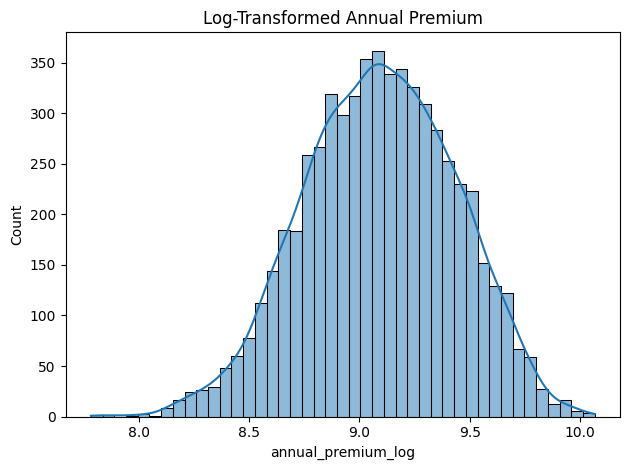

In [ ]:
cols_to_log = ['annual_income', 'prior_claims_amount', 'annual_premium']

for col in cols_to_log:
    df_engineered[f'{col}_log'] = np.log1p(df_engineered[col])

sns.histplot(df_engineered['annual_premium_log'], kde=True)
plt.title("Log-Transformed Annual Premium")
plt.tight_layout()
plt.savefig('../reports/figures/annual_premium_log_distribution.png')
plt.show()

In [6]:
cols_to_drop = ['annual_income', 'prior_claims_amount']
df_final = df_engineered.drop(columns=cols_to_drop)

df_final.to_csv('../data/processed/insurance_claims_engineered.csv', index=False)
print("Saved processed data to ../data/processed/insurance_claims_engineered.csv")

Saved processed data to ../data/processed/insurance_claims_engineered.csv
